<a href="https://colab.research.google.com/github/plasma-wastaken/REFFTO-PROJECTS/blob/main/Fakemodeltrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [ ]:
true_df=pd.read_csv('True.csv')
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake_df=pd.read_csv('Fake.csv')
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true_df['label'] = 1
fake_df['label'] = 0


In [ ]:
df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

In [ ]:
df["text"] = df["text"].apply(clean_text)

In [ ]:
df.size

224490

In [ ]:
df.shape

(44898, 5)

In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
df.duplicated().sum()

np.int64(209)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,title,text,subject,date,label
0,"Pence says U.S. will work with Japan, allies t...",tokyo reuters us vice president mike pence sa...,politicsNews,"April 18, 2017",1
1,WOW! Just When We Thought Obama’s Global Relat...,weak leadership has repercussions the european...,politics,"Oct 30, 2015",0
2,Zambia fears humanitarian crisis as influx of ...,lusaka reuters zambia fears a looming humanit...,worldnews,"September 22, 2017",1
3,U.S. jurors hear closing arguments over Iran-l...,reuters lawyers for the united states on mond...,politicsNews,"June 26, 2017",1
4,Grandma Will Have To Pay More Than $20k A Yea...,the congressional budget office released their...,News,"June 27, 2017",0


In [ ]:
df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df['title'] = df['title'].str.upper()
df.head()

,title,text,subject,date,label
0,"PENCE SAYS U.S. WILL WORK WITH JAPAN, ALLIES T...",tokyo reuters us vice president mike pence sa...,politicsNews,"April 18, 2017",1
1,WOW! JUST WHEN WE THOUGHT OBAMA’S GLOBAL RELAT...,weak leadership has repercussions the european...,politics,"Oct 30, 2015",0
2,ZAMBIA FEARS HUMANITARIAN CRISIS AS INFLUX OF ...,lusaka reuters zambia fears a looming humanit...,worldnews,"September 22, 2017",1
3,U.S. JURORS HEAR CLOSING ARGUMENTS OVER IRAN-L...,reuters lawyers for the united states on mond...,politicsNews,"June 26, 2017",1
4,GRANDMA WILL HAVE TO PAY MORE THAN $20K A YEA...,the congressional budget office released their...,News,"June 27, 2017",0


In [ ]:
df['text'] = df['text'].str.upper()
df['subject']= df['subject'].str.upper()
df.head()

,title,text,subject,date,label
0,"PENCE SAYS U.S. WILL WORK WITH JAPAN, ALLIES T...",TOKYO REUTERS US VICE PRESIDENT MIKE PENCE SA...,POLITICSNEWS,"April 18, 2017",1
1,WOW! JUST WHEN WE THOUGHT OBAMA’S GLOBAL RELAT...,WEAK LEADERSHIP HAS REPERCUSSIONS THE EUROPEAN...,POLITICS,"Oct 30, 2015",0
2,ZAMBIA FEARS HUMANITARIAN CRISIS AS INFLUX OF ...,LUSAKA REUTERS ZAMBIA FEARS A LOOMING HUMANIT...,WORLDNEWS,"September 22, 2017",1
3,U.S. JURORS HEAR CLOSING ARGUMENTS OVER IRAN-L...,REUTERS LAWYERS FOR THE UNITED STATES ON MOND...,POLITICSNEWS,"June 26, 2017",1
4,GRANDMA WILL HAVE TO PAY MORE THAN $20K A YEA...,THE CONGRESSIONAL BUDGET OFFICE RELEASED THEIR...,NEWS,"June 27, 2017",0


<Axes: xlabel='label', ylabel='count'>

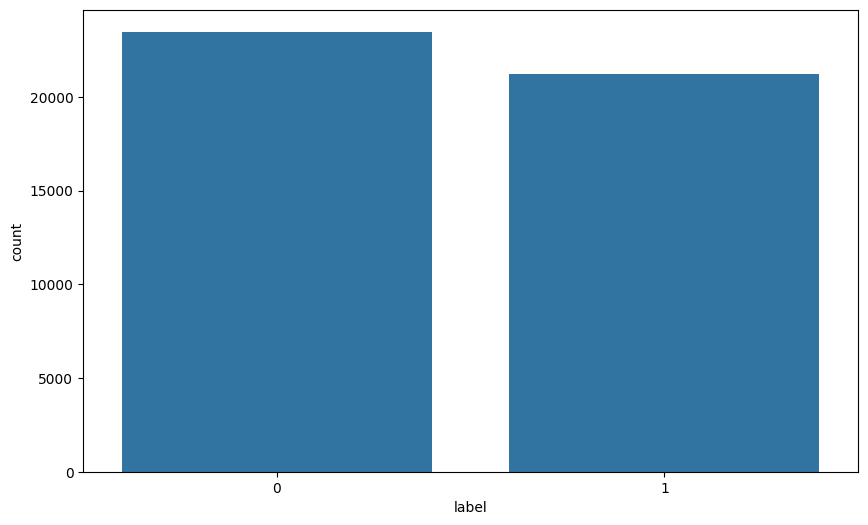

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='label',data=df)

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

In [ ]:
from sklearn.model_selection import train_test_split

X_text = df['text']
X_extra = df[['word_count']]
y = df['label']

X_train_text, X_test_text, X_train_extra, X_test_extra, y_train, y_test = train_test_split(
    X_text, X_extra, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

In [ ]:
X_train_final = X_train_vec
X_test_final = X_test_vec

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9850078317296934


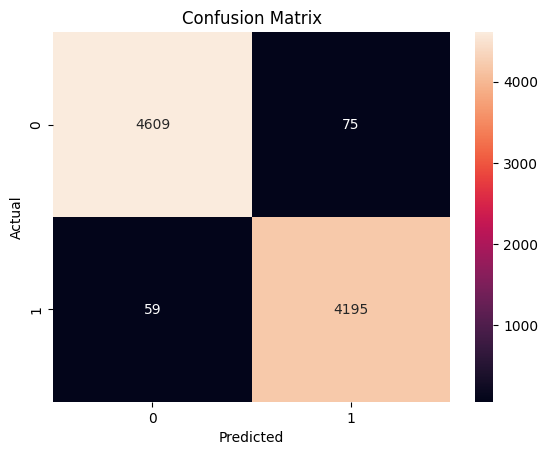

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_final, y_train)

nb_pred = nb.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.9377936898635041


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_final, y_train)

svm_pred = svm.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.9945177892145894


In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Logistic Regression: 0.9850078317296934
Naive Bayes: 0.9377936898635041
SVM: 0.9945177892145894


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=30, max_depth=10 )
rf.fit(X_train_final, y_train)

rf_pred = rf.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9622958156187067


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier( max_depth=10)
dt.fit(X_train_final, y_train)

dt_pred = dt.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.9963078988588051


In [ ]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))

Logistic Regression: 0.9850078317296934
Naive Bayes: 0.9377936898635041
SVM: 0.9945177892145894
Random Forest: 0.9622958156187067
Decision Tree: 0.9963078988588051


In [ ]:
from sklearn.metrics import accuracy_score

train_pred = svm.predict(X_train_final)

test_pred = svm.predict(X_test_final)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9997482587899639
Test Accuracy: 0.9945177892145894


# the above step shows that train and test both accuracies are 99% which means the model is stable

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4684
           1       0.99      1.00      0.99      4254

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm, X_train_final, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.99426654 0.99356643 0.99496503 0.99202797 0.99384615]
Average CV score: 0.9937344261108769


In [ ]:
print("SVM:", accuracy_score(y_test, svm_pred))

SVM: 0.9945177892145894


In [ ]:
import joblib


In [ ]:
joblib.dump(vectorizer,"vectorizer.jb")
joblib.dump(svm,"svm.jb")

['svm.jb']